# Análisis de Absentismo Laboral - RRHH

---

### Preguntas de negocio

> ¿Qué variables personales y laborales están más asociadas a niveles elevados de absentismo?  
> Cómo ajustamos nuestras políticas internas para abordar proactivamente estos perfiles de riesgo y reducir las ausencias?


### Pasos:

1. Construir un modelo que permita distinguir entre empleados con absentismo elevado y el resto.
2. Identificar qué variables están asociadas a esa diferencia.

### Definición de "Absentismo_Alto"

Se define como absentismo elevado cuando el total de horas acumuladas de un empleado supera el percentil 75 (P75). La variable resultante es binaria: 1 si el empleado supera el umbral, 0 si no lo supera.

### Justificación metodológica

El EDA de la semana volvió a mostrar una distribución asimétrica de las horas de absentismo. La pregunta de negocio es *quién tiene riesgo elevado*, el diseño gira alrededor de una variable binaria (`Absentismo_Alto`) y no las horas totales.

### Metodología:

1. **Agregación por empleado.** Los 800 registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (136 empleados), para garantizar la independencia de las observaciones.

2. **Análisis bivariante no paramétrico.** Se compara cada variable entre los dos grupos (absentismo alto vs. resto). Se usan tests no paramétricos porque `Total_Horas_Absentismo` sigue siendo asimétrica incluso tras la agregación: Spearman para variables numéricas, Mann-Whitney para binarias y Kruskal-Wallis para categóricas con más de dos niveles.

3. **Regresión logística.** Permite estimar la probabilidad de pertenecer al grupo de absentismo alto en función de múltiples variables simultáneamente, controlando el efecto del resto. Los coeficientes se interpretan como Odds Ratios: un OR > 1 indica mayor probabilidad asociada a esa variable; OR < 1 indica menor probabilidad.

Los resultados no seran = a relaciones causales.

## 1. Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

import os
from dotenv import load_dotenv

## 2. Carga de datos

In [4]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados correctamente desde el archivo CSV.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Las variables personales y sociodemográficas estables a lo largo del tiempo se conservan con el **primer valor** (first) registrado.
- Las variables que pueden variar entre episodios (carga de trabajo, hit target) se resumen con la **media**.

In [5]:
df_modelo = (
    df
    .groupby("ID_Employee")
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),

        # Variables personales
        Age=("Age", "first"),
        Education=("Education", "first"),
        Son=("Son", "first"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Pet=("Pet", "first"),
        Body_Mass_Index=("Body_Mass_Index", "first"),

        # Variables laborales
        Service_Time=("Service_Time", "first"),
        Transportation_Expense=("Transportation_Expense", "mean"),
        Distance_Residence_Work=("Distance_Residence_Work", "first"),
        Work_load_Average_Day=("Work_load_Average_Day", "mean"),
        Hit_Target=("Hit_Target", "mean")
    )
    .reset_index()
)
df_modelo

,ID_Employee,Total_Horas_Absentismo,Age,Education,Son,Social_Drinker,Social_Smoker,Pet,Body_Mass_Index,Service_Time,Transportation_Expense,Distance_Residence_Work,Work_load_Average_Day,Hit_Target
0,1,121,37,3,1,0,0,1,29,14,235.0,11,262.894478,95.173913
1,2,25,48,1,1,0,1,5,33,12,235.0,29,241.597000,93.333333
2,3,444,38,1,0,1,0,0,31,18,179.0,51,264.747216,94.762887
3,4,0,40,1,1,1,0,8,34,13,118.0,14,271.219000,95.000000
4,5,102,43,1,1,1,0,0,38,13,235.0,20,266.741389,91.722222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,132,0,36,1,2,0,1,4,21,11,378.0,49,237.656000,99.000000
132,133,3,32,3,0,0,0,0,25,8,235.0,16,222.196000,99.000000
133,134,2,50,1,1,1,0,0,31,18,118.0,13,261.306000,97.000000
134,135,8,40,2,2,0,1,0,22,17,179.0,22,306.345000,93.000000


### 3.2 Definición de Absentismo_Alto

Se clasifica como absentismo elevado los empleados con suma total de horas de ausencia > P75 (percentil 75). El resultado es una variable binaria: **1** = absentismo alto, **0** = resto.

In [6]:

umbral_alto = df_modelo["Total_Horas_Absentismo"].quantile(0.75)

df_modelo["Absentismo_Alto"] = (
    df_modelo["Total_Horas_Absentismo"] >= umbral_alto
).astype(int)

print("Umbral de absentismo alto:", umbral_alto)
print(df_modelo["Absentismo_Alto"].value_counts())

Umbral de absentismo alto: 21.75
Absentismo_Alto
0    102
1     34
Name: count, dtype: int64


## 4. Análisis bivariante

Antes del modelo multivariable, se compara cada variable entre los dos grupos: empleados con absentismo alto (Absentismo_Alto = 1) y el resto (Absentismo_Alto = 0). El objetivo es identificar qué variables presentan diferencias relevantes entre grupos.

Se usan tests no paramétricos porque la distribución de las horas sigue siendo asimétrica tras la agregación:
- **Spearman**: variables numéricas continuas
- **Mann-Whitney U**: variables binarias (Sí/No)
- **Kruskal-Wallis**: Education (4 niveles)

In [7]:
print('=== ANÁLISIS BIVARIANTE: Absentismo_Alto vs. resto ===\n')

# A. Spearman — variables numéricas
vars_numericas = [
    'Age', 'Son', 'Pet', 'Body_Mass_Index',
    'Service_Time', 'Transportation_Expense',
    'Distance_Residence_Work', 'Work_load_Average_Day',
    'Hit_Target'
]

print('[Correlación de Spearman con Total_Horas_Absentismo]')
for var in vars_numericas:
    r, p = stats.spearmanr(
        df_modelo[var], df_modelo['Total_Horas_Absentismo']
    )
    sig = 'Significativa' if p < 0.05 else 'No significativa'
    print(f'  {var:30} r = {r:6.3f} | p = {p:.4f} -> {sig}')

# B. Mann-Whitney — variables binarias
vars_binarias = ['Social_Drinker', 'Social_Smoker']

print('\n[Mann-Whitney U — variables binarias]')
for var in vars_binarias:
    g0 = df_modelo[
        df_modelo[var] == 0
    ]['Total_Horas_Absentismo']
    g1 = df_modelo[
        df_modelo[var] == 1
    ]['Total_Horas_Absentismo']
    stat, p = stats.mannwhitneyu(
        g0, g1, alternative='two-sided'
    )
    sig = 'Significativa' if p < 0.05 else 'No significativa'
    print(
        f'  {var:25} p = {p:.4f} | '
        f'Mediana(0)={g0.median():.0f}h '
        f'Mediana(1)={g1.median():.0f}h -> {sig}'
    )

# C. Kruskal-Wallis — Education (4 categories)
print('\n[Kruskal-Wallis — Education (4 niveles)]')
grups_edu = [
    df_modelo[
        df_modelo['Education'] == nivel
    ]['Total_Horas_Absentismo'].values
    for nivel in sorted(df_modelo['Education'].unique())
]
stat, p = stats.kruskal(*grups_edu)
sig = 'Significativa' if p < 0.05 else 'No significativa'
print(f'  Education (4 niveles): H = {stat:.3f} | p = {p:.4f} -> {sig}')

=== ANÁLISIS BIVARIANTE: Absentismo_Alto vs. resto ===

[Correlación de Spearman con Total_Horas_Absentismo]
  Age                            r = -0.059 | p = 0.4955 -> No significativa
  Son                            r =  0.191 | p = 0.0256 -> Significativa
  Pet                            r =  0.051 | p = 0.5532 -> No significativa
  Body_Mass_Index                r = -0.142 | p = 0.0987 -> No significativa
  Service_Time                   r = -0.048 | p = 0.5799 -> No significativa
  Transportation_Expense         r =  0.273 | p = 0.0013 -> Significativa
  Distance_Residence_Work        r = -0.106 | p = 0.2185 -> No significativa
  Work_load_Average_Day          r =  0.210 | p = 0.0143 -> Significativa
  Hit_Target                     r = -0.089 | p = 0.3015 -> No significativa

[Mann-Whitney U — variables binarias]
  Social_Drinker            p = 0.7260 | Mediana(0)=8h Mediana(1)=8h -> No significativa
  Social_Smoker             p = 0.5139 | Mediana(0)=8h Mediana(1)=8h -> No sign

## 5. Modelo multivariable: Regresión logística

La regresión logística estima la **probabilidad** de que un empleado pertenezca al grupo de absentismo alto, en función de sus características personales y laborales, controlando el efecto del resto de variables simultáneamente.

Las variables numéricas se estandarizan (media = 0, desviación estándar = 1) antes de introducirlas al modelo, lo que permite comparar la magnitud de los coeficientes entre variables con escalas muy diferentes.

Los coeficientes del modelo se transforman en "**Odds Ratios (OR)**":
- **OR > 1**: la variable se asocia con mayor probabilidad de absentismo alto
- **OR < 1**: la variable se asocia con menor probabilidad de absentismo alto
- **p < 0.05**: la asociación es estadísticamente significativa

Con 136 empleados y 13 variables, el modelo está cerca del límite de lo recomendable (regla de 10 obs. por predictor). Los resultados deben interpretarse con cuidado.

In [8]:
df_modelo.groupby("Absentismo_Alto")[
    "Distance_Residence_Work"
].describe()

,count,mean,std,min,25%,50%,75%,max
Absentismo_Alto,,,,,,,,
0,102.0,29.568627,14.758458,10.0,15.25,26.0,48.75,52.0
1,34.0,25.029412,13.652584,5.0,14.00,23.5,30.50,52.0


In [9]:
# Estandarizar variables numéricas

cols_numericas = [
    "Age",
    "Son",
    "Pet",
    "Body_Mass_Index",
    "Service_Time",
    "Transportation_Expense",
    "Distance_Residence_Work",
    "Work_load_Average_Day",
    "Hit_Target"
]

for col in cols_numericas:
    df_modelo[col + "_z"] = (
        df_modelo[col] - df_modelo[col].mean()
    ) / df_modelo[col].std()

In [10]:
# Modelo: Regresión logística


formula = """
Absentismo_Alto ~
Age_z +
Son_z +
Pet_z +
Body_Mass_Index_z +
Service_Time_z +
Transportation_Expense_z +
Distance_Residence_Work_z +
Work_load_Average_Day_z +
Hit_Target_z +
C(Social_Drinker) +
C(Social_Smoker) +
C(Education)
"""

modelo_logit = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.Binomial()
).fit()

print(modelo_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        Absentismo_Alto   No. Observations:                  136
Model:                            GLM   Df Residuals:                      121
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -69.242
Date:                Fri, 10 Jul 2026   Deviance:                       138.48
Time:                        14:07:22   Pearson chi2:                     144.
No. Iterations:                    19   Pseudo R-squ. (CS):             0.1009
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## 6. Resultados

La tabla muestra los Odds Ratios de cada variable y su significación estadística. Se ordenan por magnitud del efecto (OR más alejado de 1 = mayor asociación). Las variables con p < 0.05 se consideran estadísticamente significativas en este modelo.

In [11]:
resultados = pd.DataFrame({
    "Variable": modelo_logit.params.index,
    "Coeficiente": modelo_logit.params.values,
    "P_Value": modelo_logit.pvalues.values
})

resultados = resultados[resultados["Variable"] != "Intercept"].copy()

resultados["Odds_Ratio"] = np.exp(resultados["Coeficiente"])

resultados["Variable_Limpia"] = (
    resultados["Variable"]
    .str.replace("C(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("[T.", " = ", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("_z", "", regex=False)
    .str.replace("_", " ", regex=False)
)

resultados["Fuerza_Relacion"] = -np.log10(resultados["P_Value"])

resultados = resultados.sort_values("P_Value")

resultados[[
    "Variable_Limpia",
    "Odds_Ratio",
    "P_Value",
    "Fuerza_Relacion"
]]

,Variable_Limpia,Odds_Ratio,P_Value,Fuerza_Relacion
12,Distance Residence Work,5.340661e-01,0.041663,1.380248
7,Son,1.489993e+00,0.140431,0.852536
10,Service Time,6.698560e-01,0.318376,0.497060
2,Social Smoker = 1,1.940511e+00,0.327956,0.484184
1,Social Drinker = 1,1.626971e+00,0.357823,0.446331
3,Education = 2,1.837016e+00,0.442319,0.354265
6,Age,1.241505e+00,0.459883,0.337353
13,Work load Average Day,1.146871e+00,0.527729,0.277589
8,Pet,1.126776e+00,0.614625,0.211390
11,Transportation Expense,1.120363e+00,0.635379,0.196967


**Forest plot de Odds Ratios**
Sustituye el gráfico de -log10(p), para ser más intuitivo para RRHH

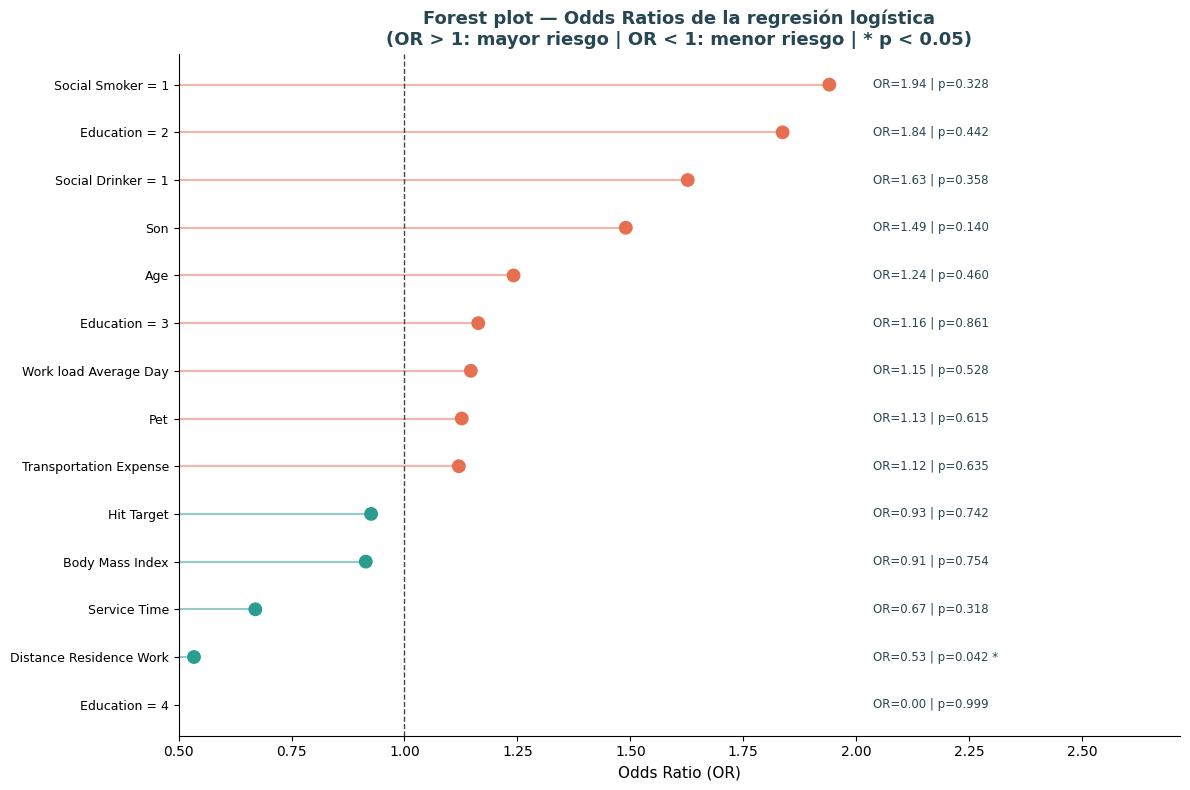

In [12]:
resultados_plot = resultados.copy()
resultados_plot = resultados_plot.sort_values(
    'Odds_Ratio', ascending=True
)

color_pos = '#E76F51'   # OR > 1: mayor riesgo
color_neg = '#2A9D8F'   # OR < 1: menor riesgo
color_texto = '#264653'

colores = [
    color_pos if or_ > 1 else color_neg
    for or_ in resultados_plot['Odds_Ratio']
]

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(
    resultados_plot['Odds_Ratio'],
    range(len(resultados_plot)),
    color=colores, s=80, zorder=3
)

for i, (_, row) in enumerate(resultados_plot.iterrows()):
    ax.hlines(
        i, 0.5, row['Odds_Ratio'],
        color=colores[i], linewidth=1.5, alpha=0.5
    )
    sig_label = (
        ' *' if row['P_Value'] < 0.05 else ''
    )
    ax.text(
        max(resultados_plot['Odds_Ratio']) * 1.05,
        i,
        f"OR={row['Odds_Ratio']:.2f} | p={row['P_Value']:.3f}{sig_label}",
        va='center', fontsize=8.5, color=color_texto
    )

ax.axvline(1, color='#444444', linewidth=1, linestyle='--')
ax.set_yticks(range(len(resultados_plot)))
ax.set_yticklabels(
    resultados_plot['Variable_Limpia'], fontsize=9
)
ax.set_xlabel('Odds Ratio (OR)', fontsize=11)
ax.set_title(
    'Forest plot — Odds Ratios de la regresión logística\n'
    '(OR > 1: mayor riesgo | OR < 1: menor riesgo | * p < 0.05)',
    fontsize=13, fontweight='bold', color=color_texto
)
ax.set_xlim(0.5, max(resultados_plot['Odds_Ratio']) * 1.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

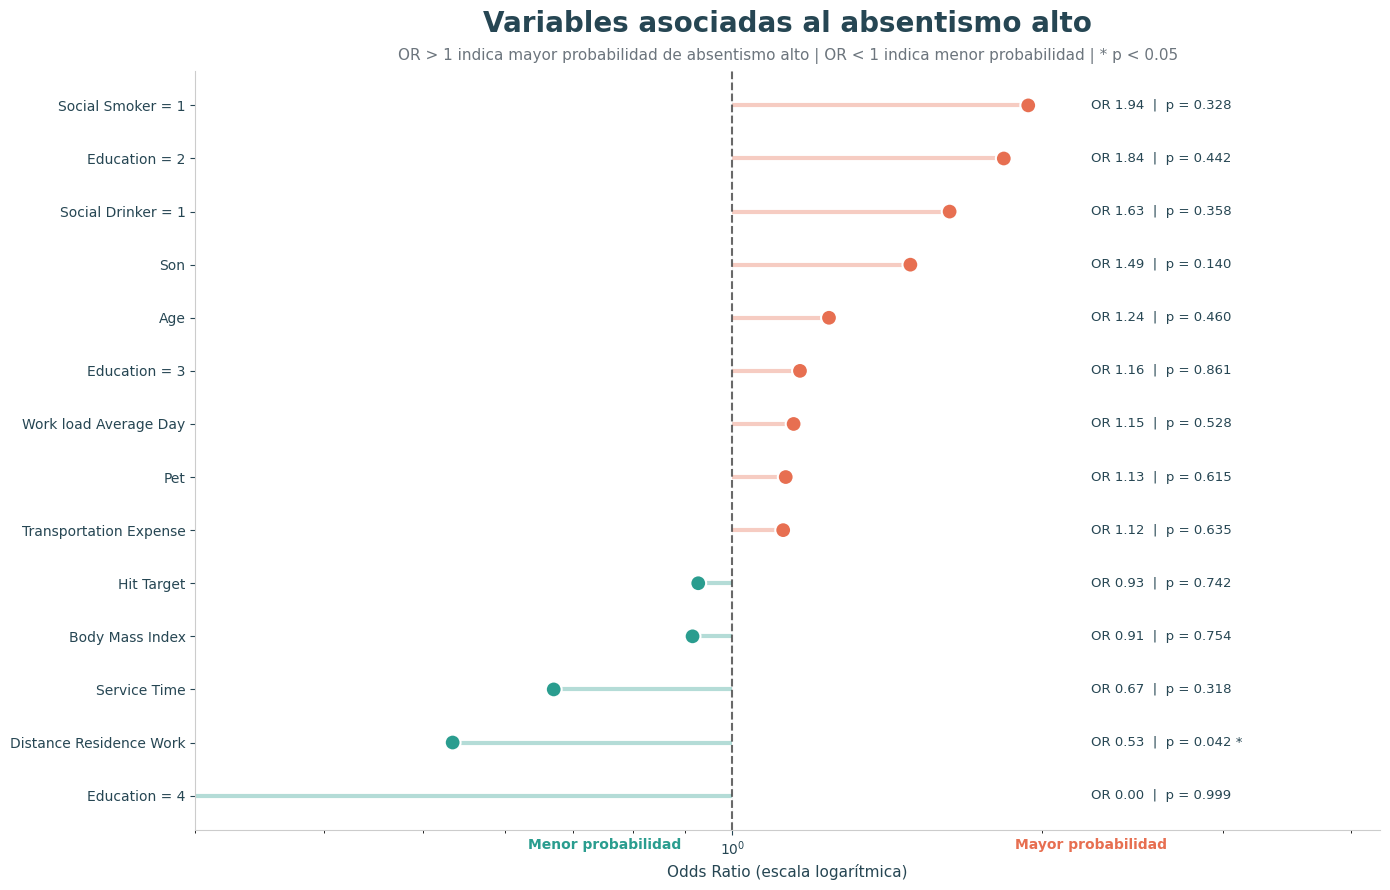

In [13]:
# ==============================
# Preparar datos
# ==============================

resultados_plot = resultados.copy()

# Ordenar: mayor OR arriba
resultados_plot = resultados_plot.sort_values(
    "Odds_Ratio",
    ascending=True
)

# Colores
color_pos = "#E76F51"      # OR > 1
color_neg = "#2A9D8F"      # OR < 1
color_ref = "#444444"
color_texto = "#264653"
color_grid = "#E5E4E4"
color_fondo = "#FFFFFF"

colores = [
    color_pos if or_ > 1 else color_neg
    for or_ in resultados_plot["Odds_Ratio"]
]

# ==============================
# Crear figura
# ==============================

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(color_fondo)
ax.set_facecolor(color_fondo)

y_pos = np.arange(len(resultados_plot))

# Líneas horizontales desde OR=1 hasta el valor OR
for i, (_, row) in enumerate(resultados_plot.iterrows()):
    color = color_pos if row["Odds_Ratio"] > 1 else color_neg
    
    ax.hlines(
        y=i,
        xmin=1,
        xmax=row["Odds_Ratio"],
        color=color,
        linewidth=3,
        alpha=0.35,
        zorder=1
    )

# Puntos OR
ax.scatter(
    resultados_plot["Odds_Ratio"],
    y_pos,
    color=colores,
    s=130,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

# Línea de referencia OR = 1
ax.axvline(
    1,
    color=color_ref,
    linewidth=1.5,
    linestyle="--",
    alpha=0.8
)

# Etiquetas OR y p-value
max_or = resultados_plot["Odds_Ratio"].max()

for i, (_, row) in enumerate(resultados_plot.iterrows()):
    sig_label = " *" if row["P_Value"] < 0.05 else ""
    etiqueta_p = "p < 0.001" if row["P_Value"] < 0.001 else f"p = {row['P_Value']:.3f}"
    
    ax.text(
        max_or * 1.15,
        i,
        f"OR {row['Odds_Ratio']:.2f}  |  {etiqueta_p}{sig_label}",
        va="center",
        fontsize=9.5,
        color=color_texto
    )

# Ejes
ax.set_yticks(y_pos)
ax.set_yticklabels(
    resultados_plot["Variable_Limpia"],
    fontsize=10,
    color=color_texto
)

ax.set_xlabel(
    "Odds Ratio (escala logarítmica)",
    fontsize=11,
    color=color_texto
)

ax.set_title(
    "Variables asociadas al absentismo alto",
    fontsize=20,
    fontweight="bold",
    color=color_texto,
    pad=28
)

ax.text(
    0.5,
    1.02,
    "OR > 1 indica mayor probabilidad de absentismo alto | OR < 1 indica menor probabilidad | * p < 0.05",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    color="#6C757D"
)

# Escala log para mejor lectura
ax.set_xscale("log")

# Límites dinámicos
min_or = resultados_plot["Odds_Ratio"].min()
ax.set_xlim(
    max(0.3, min_or * 0.65),
    max_or * 2.2
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35,
    color=color_grid
)

# Etiquetas orientativas
ax.text(
    0.75,
    -1.0,
    "Menor probabilidad",
    ha="center",
    fontsize=10,
    color=color_neg,
    fontweight="bold"
)

ax.text(
    max_or * 1.15,
    -1.0,
    "Mayor probabilidad",
    ha="center",
    fontsize=10,
    color=color_pos,
    fontweight="bold"
)

# Limpieza visual
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

ax.tick_params(axis="x", colors=color_texto)
ax.tick_params(axis="y", colors=color_texto)

plt.tight_layout()
plt.show()

## Visualizaciones

## 7. Interpretación de resultados

---

El modelo de regresión logística permite identificar qué características están asociadas con una mayor probabilidad de pertenecer al grupo de absentismo elevado, controlando el efecto del resto de variables.

Las variables con OR más alejado de 1 son las que presentan mayor asociación con el absentismo alto. Sin embargo, dado el tamaño muestral (136 empleados), ninguna variable alcanza significación estadística (p < 0.05), lo que indica que el modelo no puede hacer afirmaciones concluyentes con los datos disponibles.

Como **tendencias** (no conclusiones definitivas), las variables que muestran mayor OR positivo —es decir, mayor asociación con el absentismo elevado— son el número de hijos (`Son`), ser fumador social (`Social_Smoker`), ser bebedor social (`Social_Drinker`) y la edad (`Age`). Por el contrario, variables como `Hit_Target` o `Distance_Residence_Work` muestran OR cercano a 1, lo que indica escasa asociación con el absentismo en este dataset.

**Importante:** estas asociaciones no implican causalidad. Un OR > 1 no significa que esa característica *cause* el absentismo, sino que los empleados con esa característica tienen, en promedio, mayor probabilidad de pertenecer al cuartil superior de ausencias.

### Limitaciones

- Muestra pequeña (136 empleados) para un modelo con 13 predictores
- El umbral P75 (21.75 horas) es una decisión metodológica, no un estándar externo
- El dataset no incluye variables organizativas (puesto, equipo, turno) que probablemente tienen mayor poder explicativo

- Las asociaciones no implican causalidad
- La categoría "Education = 4" únicamente estaba representada por dos empleados, ninguno de los cuales pertenecía al grupo de alto absentismo. Esta escasa frecuencia produjo un fenómeno de separación en la regresión logística, generando un coeficiente extremo que no debe interpretarse desde el punto de vista estadístico.

## <span style="color:red">8. Conclusiones y recomendaciones</span>
---


### Respuesta a la pregunta de negocio

- Con los datos disponibles no se puede identificar un perfil de riesgo significativo a nivel estadístico. 
- El modelo de regresión logística no muestra ninguna variable con asociación significativa (p < 0.05).

VARIABLES:
- ninguna variable personal (edad, hábitos sociales, IMC, educación) muestra asociación significativa con el absentismo.

Los factores con evidencia estadística proceden del análisis bivariante, no del modelo conjunto:

- **Gasto en transporte** (r = 0.27, p = 0.001): el factor más significativo. Empleados con mayor gasto de desplazamiento acumulan más horas de ausencia.
- **Carga de trabajo diaria** (r = 0.21, p = 0.014): mayor carga se asocia con más absentismo, consistente con la literatura sobre fatiga laboral.
- **Número de hijos** (r = 0.19, p = 0.026): más responsabilidades familiares se asocian con más ausencias, probablemente por motivos de conciliación.

Desde RRHH se puede aplicar acciones en los 3, a diferencia de variables como la edad o el tabaquismo.

### <span style="color:green">Recomendaciones para RRHH </span>
Dado que el análisis no permite señalar perfiles con significación estadística, las recomendaciones son de momento generales en base al análisis bivariante:

1. Encuesta interna para conocer el método de transporte habitual al trabajo para luego estudiar políticas de minimización del gasto en transporte como:
        -Retribución flexible (posibilidad de comprar tiquets de transporte público antes de tributar toda la nómina en el IRPF). Coste plataforma Cobee: mínimo75€/mes (hasta 75 trabajadores).
        -Parking de bicicletas protegido - 1500€ (y servicios asociados como ducha, estación mecánica, etc.). 
        -Estudiar acuerdo de car sharing público (Tribbu) o privado (HYBO, plataforma de carpooling corporativo entre empleados de una empresa entre 2-5€/mes por trabajador)
2. Revisar la carga de trabajo en los meses identificados como críticos (marzo y julio).
3. Realizar una entrevista individual para empleados con hijos, que permita estudiar los horarios y cargos en relación a la conciliación familiar.



### Líneas futuras

- Ampliar el período de análisis para tener más registros en el estudio
- Incorporar variables organizativas (turno, equipo/ruta, supervisor)
- Explorar modelos de machine learning para detectar interacciones entre variables

# RESUMEN
- La regresión logística identificó únicamente una variable significativamente asociada al riesgo de presentar un nivel elevado de absentismo: la distancia entre la residencia y el lugar de trabajo (OR = 0,53; p = 0,042). Los empleados con mayor distancia a la empresa presentan una menor probabilidad de pertenecer al grupo de alto absentismo. Es posible que esta variable esté reflejando otros factores no incluidos en el modelo, por lo que sería recomendable profundizar en su análisis en futuros estudios.

- El resto de variables incluidas en el modelo no mostraron asociaciones estadísticamente significativas, aunque algunas como el número de hijos o el hábito de fumar presentaron tendencias que podrían investigarse si hubieran más registros.  
- En conjunto, el modelo muestra una capacidad explicativa moderada (Pseudo R² = 0,10), lo que sugiere que el absentismo también depende de otros factores personales, organizativos y de salud no recogidos en esta base de datos. 

